## 1e Trial By Trial plot

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd
import os
import glob
import re
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle

In [3]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

cycle4_1 = [2,4,1,3]
cycle4_2 = [3,4,2,1]
cycle4_3 = [1,2,3,4]
cycle4_4 = [3,1,4,2]
cycle4_5 = [1,2,4,3]
cycle4_6 = [4,3,2,1]

[2026-02-01 10:16:17,031][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
animal = "eliot"
day = "20221019"

In [5]:
nwb_file_name = animal.lower() + day + '.nwb'

nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

print(nwb_copy_file_name)
session_interval, position_interval = runSessionNames(nwb_copy_file_name)
print(session_interval)
session_name = session_interval[0]
            
q = {"nwb_file_name": nwb_copy_file_name,
     "epoch": session_name[:2],
    "proportion": 0.1,
     "delta_t_minus":5, "delta_t_plus":5,
     "max_flag":1}

df = ChangeofMind().fetch1_dataframe(q)   

eliot20221019_.nwb
['02_Seq2Session1', '04_Seq2Session2', '06_Seq2Session3', '08_Seq2Session4', '10_Seq2Session5']


In [7]:
df

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,CoMMaxProportion,initial_choice,initial_time,proportion_arm1,...,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,CoM_arm,current,future_H,future_O,past,past_reward
1,1.666198e+09,1.0,1.666198e+09,4.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],4.0,4.0,2.0,NaN,NaN
2,1.666198e+09,1.0,1.666198e+09,2.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],2.0,2.0,3.0,4.0,NaN
3,1.666198e+09,1.0,1.666198e+09,3.0,2.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],3.0,3.0,1.0,2.0,NaN
4,1.666198e+09,1.0,1.666198e+09,1.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],1.0,1.0,4.0,3.0,3.0
5,NaN,NaN,1.666198e+09,4.0,0.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],4.0,4.0,2.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,1.666200e+09,1.0,1.666200e+09,4.0,2.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],4.0,4.0,1.0,2.0,3.0
79,1.666200e+09,1.0,1.666200e+09,1.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],1.0,1.0,3.0,4.0,4.0
80,1.666200e+09,1.0,1.666200e+09,3.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],3.0,3.0,1.0,1.0,4.0
81,1.666200e+09,1.0,1.666200e+09,1.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],1.0,1.0,NaN,3.0,4.0


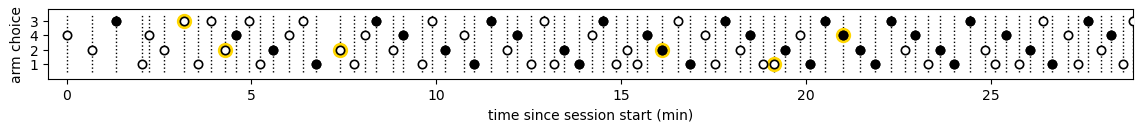

In [130]:
min_num = 0
max_num = 80

t0 = np.array(df.loc[min_num:max_num].timestamp_H)
t1 = np.array(df.loc[min_num:max_num].timestamp_O)
outers = df.loc[min_num:max_num].OuterWellIndex #outer arm choice
rewarded = df.loc[min_num:max_num].rewardNum == 2

illegal = df.loc[min_num:max_num].rewardNum == 0
com = df.loc[min_num:max_num].change_of_mind


# arange_type
seqn = cycle4_2

fig,axes=plt.subplots(1,1,sharex=True,figsize=(14,0.9))

ax = axes
for t in t1:
    ax.plot([t,t],[-0.5,3.5],'k:',linewidth=1, zorder = 0)
        
    # choices, rewards etc
for a in range(4): # arm 1-4
    a_trials=np.argwhere(outers==seqn[a]).ravel()
    trials_time = t1[a_trials]
    ax.scatter(trials_time,3-a*np.ones_like(a_trials),linewidths=1.2,edgecolors='k',facecolor=[1,1,1],zorder = 4)
            
    rewarded_a=np.argwhere(np.logical_and(outers==seqn[a],rewarded)).ravel();
    trials_time = t1[rewarded_a]
    ax.scatter(trials_time,3-a*np.ones_like(rewarded_a),edgecolors='k',facecolor='k',zorder = 5);
            
    illegal_a=np.argwhere(np.logical_and(outers==seqn[a],illegal)).ravel();
    ax.scatter(illegal_a,3-a*np.ones_like(illegal_a),edgecolors='C'+str(a),facecolor=[0.1,0.1,0.1]);

    com_a=np.argwhere(np.logical_and(outers==seqn[a],com)).ravel();
    trials_time = t1[com_a]
    ax.scatter(trials_time,3 - a*np.ones_like(com_a),edgecolors='gold',facecolor="gold",s = 100,zorder = 1);
         
ax.set_yticks(np.arange(4))
ax.set_yticklabels(seqn[::-1])
ax.set_ylabel('arm choice')
ax.set_xlabel('time since session start (min)')
ax.set_ylim([-1,3.8])
ax.set_xlim([t1[0]-30,t1[-1]])

xticks = np.arange(t1[0], t1[-1], 5*60)
ax.set_xticks(xticks);
ax.set_xticklabels([str(int(np.round(t/60))) for t in xticks - t0[0]]);
plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1/choice_in_time_learning_{nwb_copy_file_name}_{session_name}.pdf',dpi=300,bbox_inches='tight')
#axes.set_title(data['date_session'][s]+' '+data['seq'][s],loc='left')
        
        